In [1]:
import json

path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/Benchmark_ Ukraine 3C_ test n1335 r100 sdb8-956/Ukraine data, test n1335 r100 sdb8-956.json"

with open(path, 'r') as f:
    data = json.load(f)
    first_key = list(data.keys())[0]
    print(f"Keys yang tersedia di record {first_key}: {list(data[first_key].keys())}")

Keys yang tersedia di record 20220105091750400: ['type', 'station', 'station latitude', 'station longitude', 'snr (db)', 'ML', 'origin time (UTC)', 'event latitude', 'event longitude', 'event distance (km)', 'yield min (kg)', 'yield max (kg)', 'norm', 'Z', 'Z_noise']


In [2]:
import json
path = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/Ukraine_1C_golden_standard.json"
with open(path, 'r') as f:
    data = json.load(f)
    labels = set([record['type'] for record in data.values()])
    print(f"Label yang ada di data Ukraine: {labels}")

Label yang ada di data Ukraine: {'qb'}


In [1]:
import pandas as pd

# Path metadata
CSV_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'

# 1. Load 100.000 baris pertama saja agar cepat
print("Loading metadata...")
df_check = pd.read_csv(CSV_PATH, low_memory=False, nrows=100000)

# 2. Cek distribusi kategori data
print("\n--- Distribusi Kategori (100.000 Baris Pertama) ---")
print(df_check['trace_category'].value_counts())

# 3. Cek 5 baris pertama untuk melihat struktur
print("\n--- Sampel 5 Baris Pertama ---")
display(df_check[['trace_name', 'trace_category', 'p_arrival_sample']].head())

# 4. Cek apakah ada Earthquake di 100.000 pertama
has_eq = 'earthquake_local' in df_check['trace_category'].values
print(f"\nApakah ada Earthquake di batch ini? {has_eq}")

Loading metadata...

--- Distribusi Kategori (100.000 Baris Pertama) ---
trace_category
noise    100000
Name: count, dtype: int64

--- Sampel 5 Baris Pertama ---


,trace_name,trace_category,p_arrival_sample
0,113A.AE_20180115001730_NO,noise,NaN
1,113A.AE_20180115003336_NO,noise,NaN
2,113A.AE_20180115020106_NO,noise,NaN
3,113A.AE_20180115022906_NO,noise,NaN
4,113A.AE_20180115035100_NO,noise,NaN



Apakah ada Earthquake di batch ini? False


In [2]:
import pandas as pd
import json
import os
import glob
from datetime import datetime

def extract_metrics_from_ssd(folder_path, output_excel="rekap_benchmark_ssd.xlsx"):
    # 1. Mencari semua file JSON di folder SSD Bapak
    search_pattern = os.path.join(folder_path, "*.json")
    json_files = glob.glob(search_pattern)
    
    if not json_files:
        print(f"Peringatan: Tidak ada file JSON ditemukan di {folder_path}")
        return

    data_list = []

    for file in json_files:
        with open(file, 'r') as f:
            try:
                content = json.load(f)
                
                # 2. Mengambil variabel metrik secara otomatis
                # Menggunakan .get() agar kode tidak error jika kunci tidak ditemukan
                row = {
                    "Waktu_Proses": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                    "Nama_File": os.path.basename(file),
                    "Accuracy": content.get("Accuracy (avg.)"),
                    "F1_Score": content.get("F1-score (avg.)"),
                    "TPR": content.get("True positive rate (avg.)"),
                    "FPR": content.get("False positive rate (avg.)")
                }
                data_list.append(row)
            except Exception as e:
                print(f"Gagal membaca file {file}: {e}")

    # 3. Membuat Tabel dan Simpan ke Excel
    df_result = pd.DataFrame(data_list)
    
    # Simpan ke folder yang sama dengan skrip atau tentukan path spesifik
    df_result.to_excel(output_excel, index=False)
    print(f"\n[SUKSES] Berhasil mengekstrak {len(data_list)} file ke {output_excel}")

# --- EKSEKUSI ---
path_ssd = '/Volumes/Extreme SSD/mcu_quake_bis_stead_output_3c'
extract_metrics_from_ssd(path_ssd)


[SUKSES] Berhasil mengekstrak 13 file ke rekap_benchmark_ssd.xlsx


In [3]:
import pandas as pd
import json
import os
import glob
from datetime import datetime

def ekstrak_json_1c_ke_excel(folder_path, output_name="rekap_benchmark_1C_total.xlsx"):
    # 1. Mencari semua file .json di path SSD Bapak
    path_pencarian = os.path.join(folder_path, "*.json")
    daftar_file = glob.glob(path_pencarian)
    
    if not daftar_file:
        print(f"Peringatan: Tidak ditemukan file JSON di {folder_path}")
        return

    hasil_ekstraksi = []

    for file_path in daftar_file:
        with open(file_path, 'r') as f:
            try:
                data = json.load(f)
                
                # 2. Mengambil metrik secara otomatis sesuai variabel terminal Bapak
                baris_data = {
                    "Waktu_Ekstraksi": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                    "Nama_File": os.path.basename(file_path),
                    "Accuracy_Avg": data.get("Accuracy (avg.)"),
                    "F1_Score_Avg": data.get("F1-score (avg.)"),
                    "TPR_Avg": data.get("True positive rate (avg.)"),
                    "FPR_Avg": data.get("False positive rate (avg.)")
                }
                hasil_ekstraksi.append(baris_data)
            except Exception as e:
                print(f"Error saat membaca {file_path}: {e}")

    # 3. Konversi ke DataFrame dan simpan ke Excel
    df = pd.DataFrame(hasil_ekstraksi)
    df.to_excel(output_name, index=False)
    
    print(f"\n[SUKSES] Berhasil mengolah {len(hasil_ekstraksi)} file JSON.")
    print(f"Data tersimpan di: {output_name}")

# --- EKSEKUSI ---
# Path sesuai direktori 1C Bapak
path_1c = '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c'
ekstrak_json_1c_ke_excel(path_1c)


[SUKSES] Berhasil mengolah 13 file JSON.
Data tersimpan di: rekap_benchmark_1C_total.xlsx


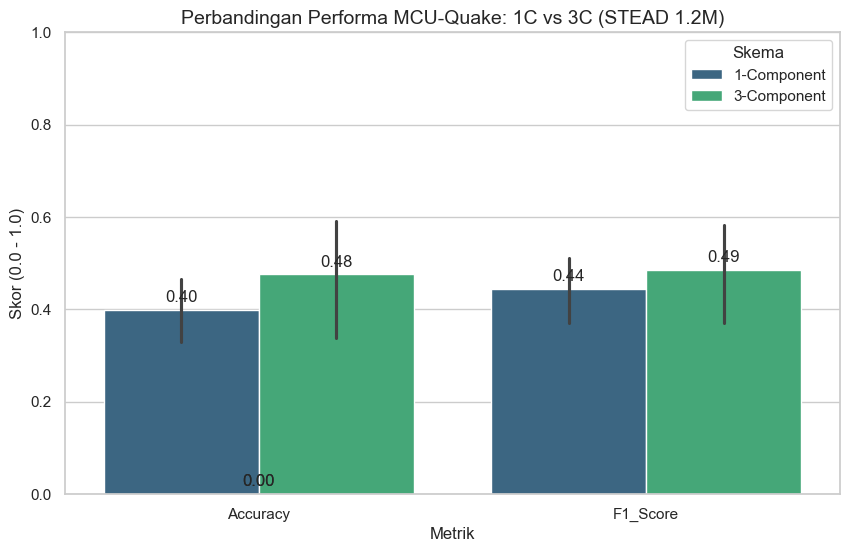

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os

def visualisasi_hasil_benchmark(folder_1c, folder_3c):
    # 1. Fungsi internal untuk membaca folder
    def ambil_data(folder, label):
        files = glob.glob(os.path.join(folder, "*.json"))
        data = []
        for f in files:
            with open(f, 'r') as j:
                content = json.load(j)
                data.append({
                    "Skema": label,
                    "Accuracy": content.get("Accuracy (avg.)"),
                    "F1_Score": content.get("F1-score (avg.)")
                })
        return data

    # 2. Ambil data dari kedua path SSD Bapak
    data_1c = ambil_data(folder_1c, "1-Component")
    data_3c = ambil_data(folder_3c, "3-Component")
    df = pd.DataFrame(data_1c + data_3c)

    # 3. Membuat Visualisasi
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Membuat grafik perbandingan metrik
    df_melted = df.melt(id_vars="Skema", var_name="Metrik", value_name="Nilai")
    ax = sns.barplot(data=df_melted, x="Metrik", y="Nilai", hue="Skema", palette="viridis")
    
    plt.title("Perbandingan Performa MCU-Quake: 1C vs 3C (STEAD 1.2M)", fontsize=14)
    plt.ylim(0, 1.0)
    plt.ylabel("Skor (0.0 - 1.0)")
    
    # Menambahkan angka di atas batang
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

    plt.show()

# --- EKSEKUSI ---
path_1c = '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c'
path_3c = '/Volumes/Extreme SSD/mcu_quake_bis_stead_output_3c'
visualisasi_hasil_benchmark(path_1c, path_3c)

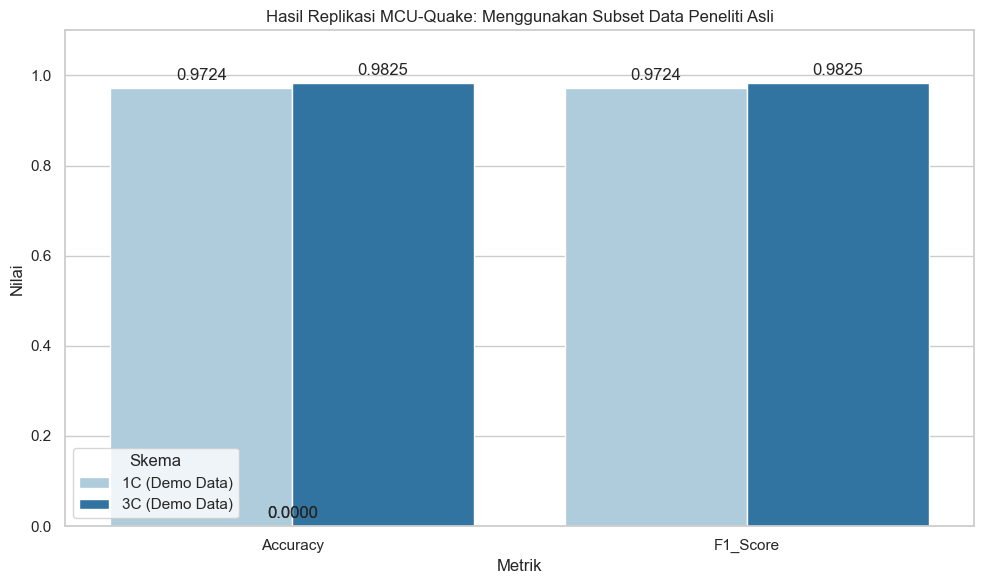

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os

def visualisasi_replikasi_orisinal(path_1c, path_3c):
    def load_data(folder, label):
        # Mencari file json di dalam folder
        files = glob.glob(os.path.join(folder, "*.json"))
        if not files: return None
        
        # Ambil file terbaru
        latest_file = max(files, key=os.path.getmtime)
        with open(latest_file, 'r') as f:
            d = json.load(f)
            return {
                "Skema": label,
                "Accuracy": d.get("Accuracy (avg.)"),
                "F1_Score": d.get("F1-score (avg.)")
            }

    # 1. Ambil data dari path demo orisinal
    res_1c = load_data(path_1c, "1C (Demo Data)")
    res_3c = load_data(path_3c, "3C (Demo Data)")
    
    # Gabungkan data
    results = [r for r in [res_1c, res_3c] if r is not None]
    df = pd.DataFrame(results)

    # 2. Plotting
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Reshape data untuk seaborn
    df_plot = df.melt(id_vars="Skema", var_name="Metrik", value_name="Nilai")
    
    plot = sns.barplot(data=df_plot, x="Metrik", y="Nilai", hue="Skema", palette="Paired")
    
    plt.title("Hasil Replikasi MCU-Quake: Menggunakan Subset Data Peneliti Asli", fontsize=12)
    plt.ylim(0, 1.1)
    
    # Menampilkan label angka presisi 4 desimal
    for p in plot.patches:
        plot.annotate(format(p.get_height(), '.4f'), 
                      (p.get_x() + p.get_width() / 2., p.get_height()), 
                      ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
path_demo_1c = '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/MCU_5-20_STEAD_Global_1C_28060416'
path_demo_3c = '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/MCU_5-20_STEAD_Global_28055707'

visualisasi_replikasi_orisinal(path_demo_1c, path_demo_3c)

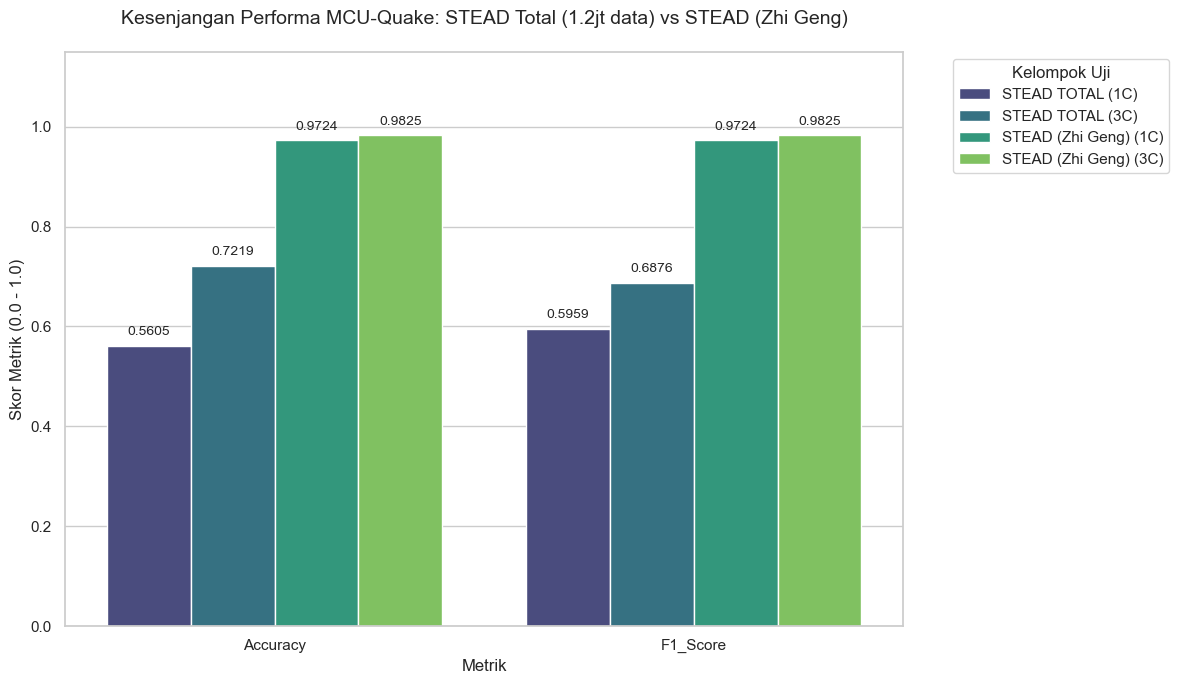

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os

def buat_grafik_gabungan(paths):
    all_data = []

    # 1. Loop untuk mengambil data dari setiap folder
    for label_data, label_skema, folder_path in paths:
        files = glob.glob(os.path.join(folder_path, "*.json"))
        if files:
            # Ambil file terbaru dari folder tersebut
            latest_file = max(files, key=os.path.getmtime)
            with open(latest_file, 'r') as f:
                d = json.load(f)
                all_data.append({
                    "Kategori": label_data,
                    "Skema": label_skema,
                    "Accuracy": d.get("Accuracy (avg.)"),
                    "F1_Score": d.get("F1-score (avg.)")
                })

    # 2. Siapkan Tabel (DataFrame)
    df = pd.DataFrame(all_data)
    # Ubah format agar sesuai untuk grafik (Metrik menjadi kolom kategori)
    df_plot = df.melt(id_vars=["Kategori", "Skema"], var_name="Metrik", value_name="Nilai")
    
    # Gabungkan label untuk sumbu X: misal "Populasi 1.2M - 1C"
    df_plot["Group"] = df_plot["Kategori"] + " (" + df_plot["Skema"] + ")"

    # 3. Plotting
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid")
    
    palette = sns.color_palette("husl", 4)
    ax = sns.barplot(data=df_plot, x="Metrik", y="Nilai", hue="Group", palette="viridis")
    
    plt.title("Kesenjangan Performa MCU-Quake: STEAD Total (1.2jt data) vs STEAD (Zhi Geng)", fontsize=14, pad=20)
    plt.ylabel("Skor Metrik (0.0 - 1.0)", fontsize=12)
    plt.ylim(0, 1.15) # Beri ruang untuk angka di atas batang
    plt.legend(title="Kelompok Uji", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Tambahkan angka di atas batang
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.4f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', fontsize=10, 
                        xytext=(0, 10), textcoords='offset points', rotation=0)

    plt.tight_layout()
    plt.show()

# --- KONFIGURASI PATH ---
# Daftar: (Label Data, Label Skema, Path Folder)
daftar_path = [
    ("STEAD TOTAL", "1C", '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c'),
    ("STEAD TOTAL", "3C", '/Volumes/Extreme SSD/mcu_quake_bis_stead_output_3c'),
    ("STEAD (Zhi Geng)", "1C", '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/MCU_5-20_STEAD_Global_1C_28060416'),
    ("STEAD (Zhi Geng)", "3C", '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/MCU_5-20_STEAD_Global_28055707')
]

buat_grafik_gabungan(daftar_path)

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import glob
import os

def plot_distribusi_embedding_gabungan(path_1c, path_3c):
    def kumpulkan_data(folder_path, label_skema):
        json_files = glob.glob(os.path.join(folder_path, "*.json"))
        print(f"[DEBUG] Mencari di {label_skema}: ditemukan {len(json_files)} file.")
        
        data_list = []
        for file in json_files:
            with open(file, 'r') as f:
                try:
                    content = json.load(f)
                    # Ambil latent_codes dan true_labels
                    # Catatan: Pastikan key 'latent_codes' dan 'true_labels' ada di JSON Bapak
                    codes = content.get('latent_codes', [])
                    labels = content.get('true_labels', [])
                    
                    if not codes:
                        print(f"  [!] Peringatan: File {os.path.basename(file)} tidak memiliki 'latent_codes'")
                    
                    for c, l in zip(codes, labels):
                        data_list.append({"Embedding": c, "Label": l, "Skema": label_skema})
                except Exception as e:
                    print(f"  [!] Error membaca {os.path.basename(file)}: {e}")
        return data_list

    # 1. Ambil data dari SSD
    data_1c = kumpulkan_data(path_1c, "1-Component (Z)")
    data_3c = kumpulkan_data(path_3c, "3-Component (ENZ)")
    
    semua_data = data_1c + data_3c

    # 2. Validasi sebelum Plotting
    if not semua_data:
        print("\n[ERROR] Tidak ada data yang berhasil dikumpulkan. Plot dibatalkan.")
        print("Saran: Periksa apakah file JSON benar-benar ada di SSD dan memiliki key 'latent_codes'.")
        return

    df = pd.DataFrame(semua_data)

    # 3. Setup Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    sns.set_theme(style="white")
    
    colors = {"NO": "#2ecc71", "QB": "#95a5a6", "LE": "#e67e22"}

    # 4. Plotting menggunakan kolom "Skema" yang sudah divalidasi
    for i, skema in enumerate(["1-Component (Z)", "3-Component (ENZ)"]):
        subset = df[df["Skema"] == skema]
        
        if subset.empty:
            axes[i].text(0.5, 0.5, f"Data {skema} Kosong", ha='center')
            continue
            
        sns.kdeplot(data=subset, x="Embedding", hue="Label", 
                    fill=True, palette=colors, ax=axes[i], 
                    common_norm=False, alpha=0.5, linewidth=2)
        axes[i].set_title(f"Distribusi Embedding: {skema}", fontsize=14)
        axes[i].set_xlabel("Latent Code Value")

    plt.suptitle("Analisis Pemisahan Sinyal MCU-Quake (1.2M STEAD)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Jalankan kembali dengan path Bapak
ssd_1c = '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c'
ssd_3c = '/Volumes/Extreme SSD/mcu_quake_bis_stead_output_3c'
plot_distribusi_embedding_gabungan(ssd_1c, ssd_3c)

[DEBUG] Mencari di 1-Component (Z): ditemukan 13 file.
  [!] Peringatan: File checkpoint_1c_100000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_200000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_300000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_400000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_500000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_600000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_700000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_800000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_900000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_1000000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_1100000.json tidak memiliki 'latent_codes'
  [!] Peringatan: File checkpoint_1c_1200000.json tidak memiliki 'latent_c

In [17]:
import json

# Pilih salah satu file dari log Bapak tadi
file_test = '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c/FINAL_STEAD_1.2M_1C_20260429_0901.json'

with open(file_test, 'r') as f:
    data = json.load(f)
    print("Kunci (Keys) yang tersedia di file Anda:")
    print(data.keys())
    
    # Intip sedikit isinya untuk memastikan letak datanya
    for key in data.keys():
        print(f"\nContoh isi dari '{key}': {str(data[key])[:100]}...")

Kunci (Keys) yang tersedia di file Anda:
dict_keys(['Accuracy', 'Accuracy (avg.)', 'True positive rate', 'True positive rate (avg.)', 'True negative rate', 'True negative rate (avg.)', 'Positive predictive value', 'Positive predictive value (avg.)', 'Negative predictive value', 'Negative predictive value (avg.)', 'False positive rate', 'False positive rate (avg.)', 'False negative rate', 'False negative rate (avg.)', 'False discovery rate', 'False discovery rate (avg.)', 'F1-score', 'F1-score (avg.)'])

Contoh isi dari 'Accuracy': [0.5604851358024692, 0.5604851358024692]...

Contoh isi dari 'Accuracy (avg.)': 0.5604851358024692...

Contoh isi dari 'True positive rate': [0.13090312879630966, 0.6586552695158896]...

Contoh isi dari 'True positive rate (avg.)': 0.5604851358024692...

Contoh isi dari 'True negative rate': [0.6586552695158896, 0.13090312879630966]...

Contoh isi dari 'True negative rate (avg.)': 0.22907326250973017...

Contoh isi dari 'Positive predictive value': [0.0805760

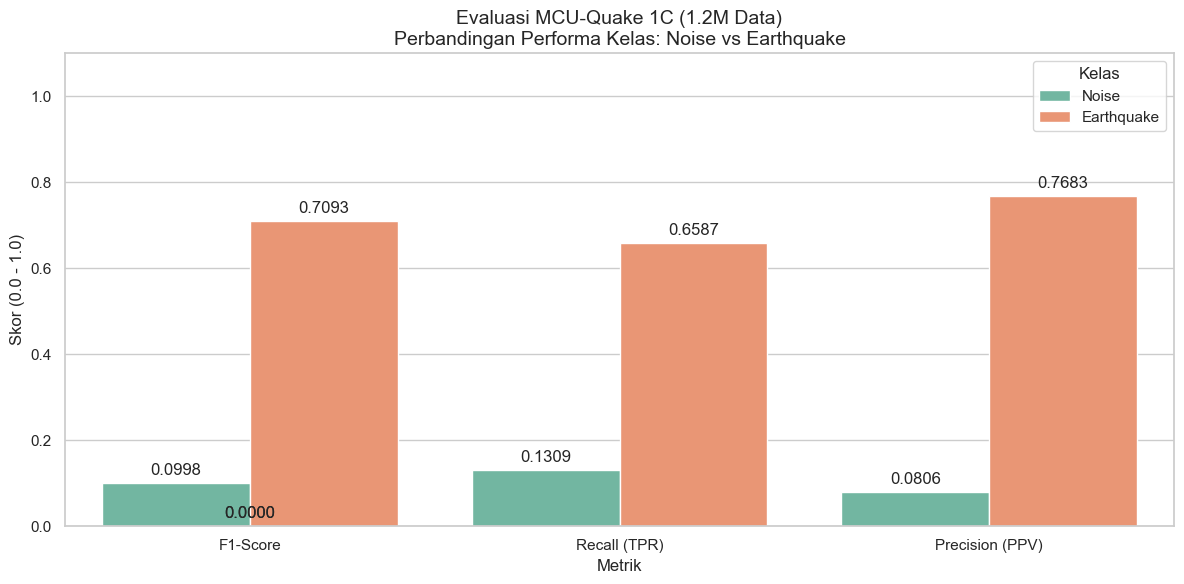

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

def visualisasi_performa_per_kelas(path_json, judul="Analisis Performa"):
    # 1. Membaca file JSON
    if not os.path.exists(path_json):
        print(f"File tidak ditemukan: {path_json}")
        return

    with open(path_json, 'r') as f:
        data = json.load(f)

    # 2. Mengambil metrik yang berbentuk list [Kelas_0, Kelas_1]
    # Kita ambil F1-Score, TPR (Recall), dan Precision (PPV)
    try:
        metrics_data = {
            "Metrik": ["F1-Score", "F1-Score", "Recall (TPR)", "Recall (TPR)", "Precision (PPV)", "Precision (PPV)"],
            "Kelas": ["Noise", "Earthquake", "Noise", "Earthquake", "Noise", "Earthquake"],
            "Nilai": [
                data["F1-score"][0], data["F1-score"][1],
                data["True positive rate"][0], data["True positive rate"][1],
                data["Positive predictive value"][0], data["Positive predictive value"][1]
            ]
        }
    except KeyError as e:
        print(f"Kesalahan: Kunci {e} tidak ditemukan dalam JSON.")
        return

    df = pd.DataFrame(metrics_data)

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Membuat grafik batang berkelompok
    ax = sns.barplot(data=df, x="Metrik", y="Nilai", hue="Kelas", palette="Set2")
    
    plt.title(f"{judul}\nPerbandingan Performa Kelas: Noise vs Earthquake", fontsize=14)
    plt.ylim(0, 1.1)
    plt.ylabel("Skor (0.0 - 1.0)")
    
    # Menambahkan label angka di atas batang
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Gunakan path file 1C atau 3C Bapak
path_1c = '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c/FINAL_STEAD_1.2M_1C_20260429_0901.json'
visualisasi_performa_per_kelas(path_1c, judul="Evaluasi MCU-Quake 1C (1.2M Data)")

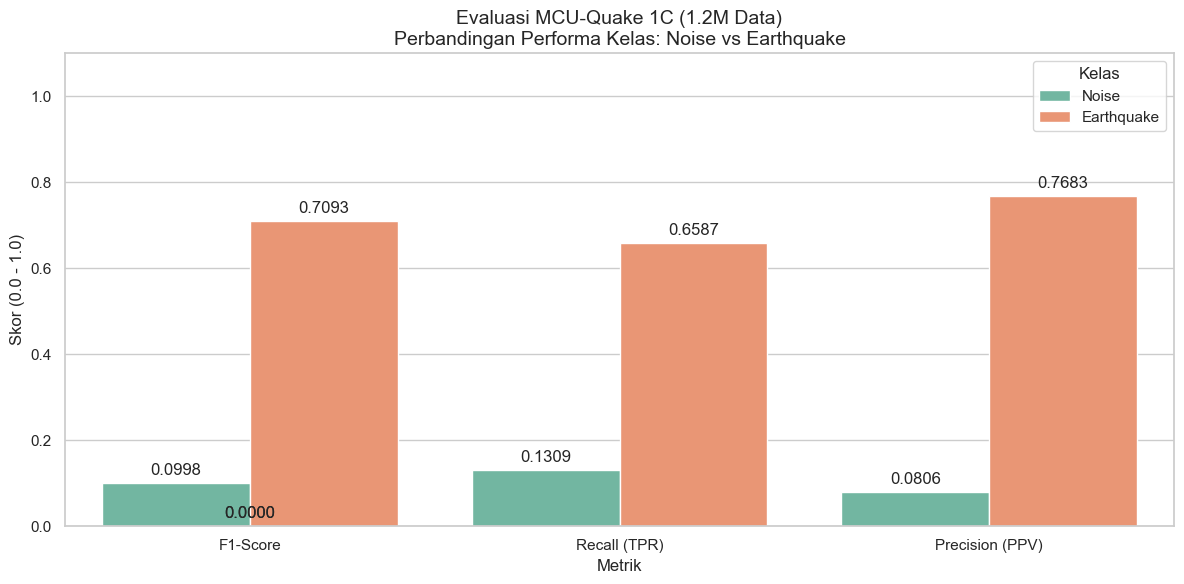

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

def visualisasi_performa_per_kelas(path_json, judul="Analisis Performa"):
    # 1. Membaca file JSON
    if not os.path.exists(path_json):
        print(f"File tidak ditemukan: {path_json}")
        return

    with open(path_json, 'r') as f:
        data = json.load(f)

    # 2. Mengambil metrik yang berbentuk list [Kelas_0, Kelas_1]
    # Kita ambil F1-Score, TPR (Recall), dan Precision (PPV)
    try:
        metrics_data = {
            "Metrik": ["F1-Score", "F1-Score", "Recall (TPR)", "Recall (TPR)", "Precision (PPV)", "Precision (PPV)"],
            "Kelas": ["Noise", "Earthquake", "Noise", "Earthquake", "Noise", "Earthquake"],
            "Nilai": [
                data["F1-score"][0], data["F1-score"][1],
                data["True positive rate"][0], data["True positive rate"][1],
                data["Positive predictive value"][0], data["Positive predictive value"][1]
            ]
        }
    except KeyError as e:
        print(f"Kesalahan: Kunci {e} tidak ditemukan dalam JSON.")
        return

    df = pd.DataFrame(metrics_data)

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Membuat grafik batang berkelompok
    ax = sns.barplot(data=df, x="Metrik", y="Nilai", hue="Kelas", palette="Set2")
    
    plt.title(f"{judul}\nPerbandingan Performa Kelas: Noise vs Earthquake", fontsize=14)
    plt.ylim(0, 1.1)
    plt.ylabel("Skor (0.0 - 1.0)")
    
    # Menambahkan label angka di atas batang
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Gunakan path file 1C atau 3C Bapak
path_1c = '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c/FINAL_STEAD_1.2M_1C_20260429_0901.json'
visualisasi_performa_per_kelas(path_1c, judul="Evaluasi MCU-Quake 1C (1.2M Data)")

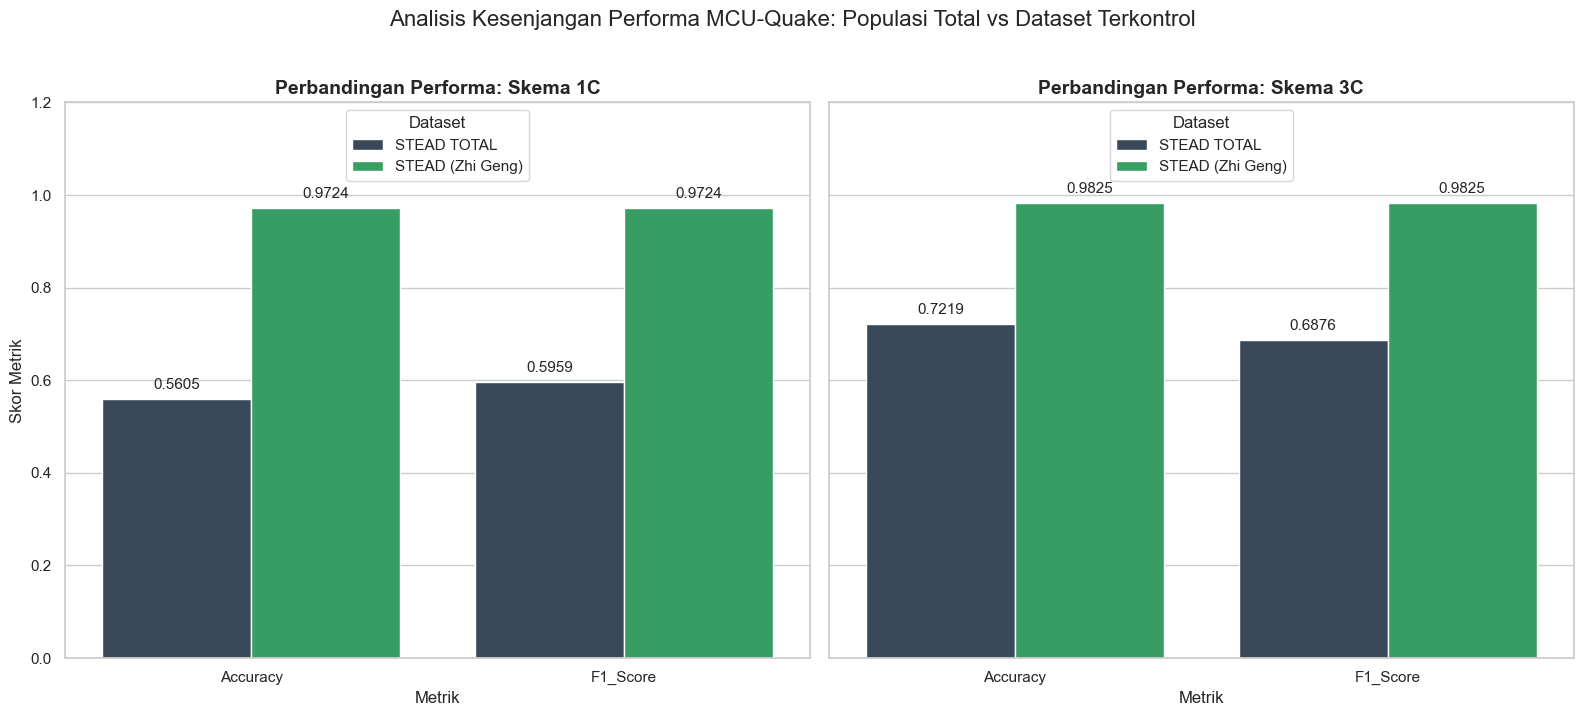

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os

def buat_grafik_terpisah_1c_3c(paths):
    all_data = []

    # 1. Ekstraksi Data
    for label_data, label_skema, folder_path in paths:
        files = glob.glob(os.path.join(folder_path, "*.json"))
        if files:
            latest_file = max(files, key=os.path.getmtime)
            with open(latest_file, 'r') as f:
                d = json.load(f)
                all_data.append({
                    "Kategori": label_data,
                    "Skema": label_skema,
                    "Accuracy": d.get("Accuracy (avg.)"),
                    "F1_Score": d.get("F1-score (avg.)")
                })

    df = pd.DataFrame(all_data)
    df_plot = df.melt(id_vars=["Kategori", "Skema"], var_name="Metrik", value_name="Nilai")

    # 2. Setup Plotting (2 Kolom: 1C dan 3C)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    sns.set_theme(style="whitegrid")
    
    skemas = ["1C", "3C"]
    colors = ["#34495e", "#27ae60"] # Biru Tua untuk Total, Hijau untuk Zhi Geng

    for i, skema in enumerate(skemas):
        # Filter data berdasarkan skema (1C atau 3C)
        subset = df_plot[df_plot["Skema"] == skema]
        
        ax = sns.barplot(data=subset, x="Metrik", y="Nilai", hue="Kategori", 
                         palette=colors, ax=axes[i])
        
        axes[i].set_title(f"Perbandingan Performa: Skema {skema}", fontsize=14, fontweight='bold')
        axes[i].set_ylim(0, 1.2)
        axes[i].set_ylabel("Skor Metrik" if i == 0 else "")
        axes[i].legend(title="Dataset", loc='upper center')

        # Tambahkan label angka di atas batang
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height:.4f}', 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', fontsize=11, 
                            xytext=(0, 10), textcoords='offset points')

    plt.suptitle("Analisis Kesenjangan Performa MCU-Quake: Populasi Total vs Dataset Terkontrol", 
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- KONFIGURASI PATH ---
daftar_path = [
    ("STEAD TOTAL", "1C", '/Volumes/Extreme SSD/mcu_quake_big_stead_output_1c'),
    ("STEAD TOTAL", "3C", '/Volumes/Extreme SSD/mcu_quake_bis_stead_output_3c'),
    ("STEAD (Zhi Geng)", "1C", '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/MCU_5-20_STEAD_Global_1C_28060416'),
    ("STEAD (Zhi Geng)", "3C", '/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/MCU_5-20_STEAD_Global_28055707')
]

buat_grafik_terpisah_1c_3c(daftar_path)

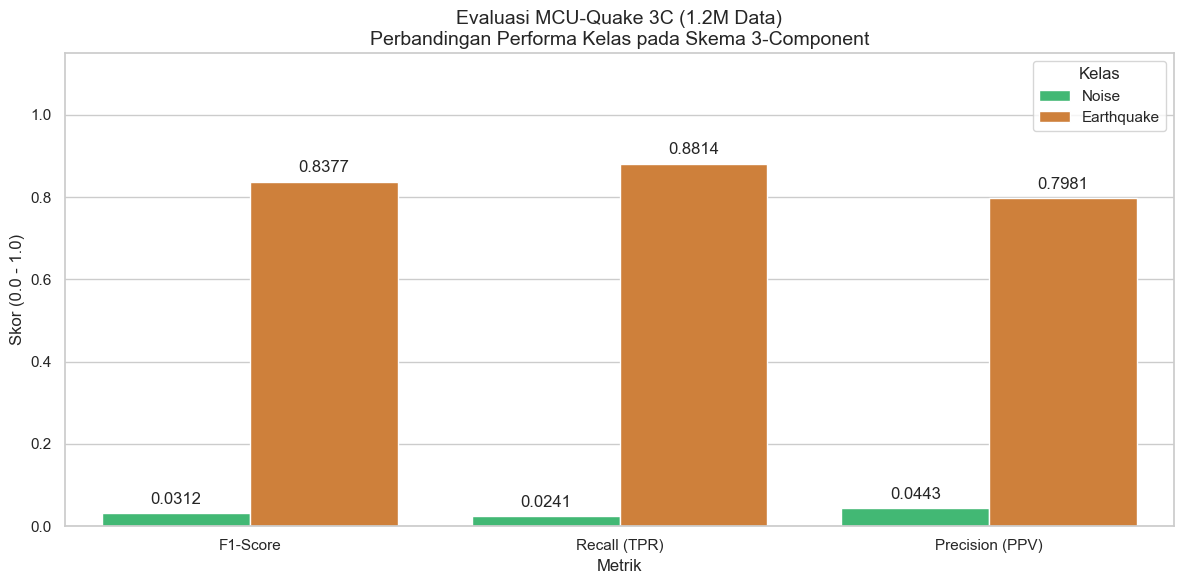

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import os

def visualisasi_performa_3c(path_json, judul="Analisis Performa 3C"):
    # 1. Membaca file JSON dari SSD Eksternal
    if not os.path.exists(path_json):
        print(f"File tidak ditemukan: {path_json}")
        return

    with open(path_json, 'r') as f:
        data = json.load(f)

    # 2. Mengambil metrik (Indeks 0: Noise, Indeks 1: Earthquake)
    try:
        metrics_data = {
            "Metrik": ["F1-Score", "F1-Score", "Recall (TPR)", "Recall (TPR)", "Precision (PPV)", "Precision (PPV)"],
            "Kelas": ["Noise", "Earthquake", "Noise", "Earthquake", "Noise", "Earthquake"],
            "Nilai": [
                data["F1-score"][0], data["F1-score"][1],
                data["True positive rate"][0], data["True positive rate"][1],
                data["Positive predictive value"][0], data["Positive predictive value"][1]
            ]
        }
    except KeyError as e:
        print(f"Kesalahan: Kunci {e} tidak ditemukan dalam JSON. Pastikan ini adalah file hasil benchmark.")
        return

    df = pd.DataFrame(metrics_data)

    # 3. Plotting menggunakan Seaborn
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Warna: Hijau Muda untuk Noise dan Oranye untuk Earthquake
    palette_colors = {"Noise": "#2ecc71", "Earthquake": "#e67e22"}
    ax = sns.barplot(data=df, x="Metrik", y="Nilai", hue="Kelas", palette=palette_colors)
    
    plt.title(f"{judul}\nPerbandingan Performa Kelas pada Skema 3-Component", fontsize=14)
    plt.ylim(0, 1.15) # Memberi ruang untuk label angka
    plt.ylabel("Skor (0.0 - 1.0)")
    
    # Menambahkan label angka presisi 4 desimal di atas setiap batang
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(format(height, '.4f'), 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha = 'center', va = 'center', 
                        xytext = (0, 10), textcoords = 'offset points')

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
# Pastikan path ini sesuai dengan file FINAL 3C di SSD Bapak
path_3c = '/Volumes/Extreme SSD/mcu_quake_bis_stead_output_3c/FINAL_STEAD_1.2M_3C_20260428_2254.json'
visualisasi_performa_3c(path_3c, judul="Evaluasi MCU-Quake 3C (1.2M Data)")